# 02. Machine Learning for Survival Analysis with `scikit-survival`

## Introduction
Traditional methods like the **Cox Proportional Hazards model** are powerful but have limitations:
1. **Linearity assumption**: They assume the log-hazard is a linear function of covariates.
2. **Interactions**: Complex interactions must be manually specified.

**Machine Learning (ML)** methods, particularly tree-based ensembles, can automatically learn non-linear relationships and complex interactions.

### Goal
In this notebook, we will:
1. Prepare data for `scikit-survival`.
2. Train a **Random Survival Forest (RSF)**.
3. Train a **Gradient Boosting Survival Analysis** model.
4. Evaluate models using the **Concordance Index (C-index)**.

In [1]:
# Install scikit-survival
!pip install scikit-survival pandas matplotlib numpy scikit-learn

  Using cached scikit_learn-1.7.2-cp312-cp312-win_amd64.whl.metadata (11 kB)
   ---------------------------------------- 0.0/807.2 kB ? eta -:--:--
   ---------------------------------------- 807.2/807.2 kB 5.9 MB/s eta 0:00:00
Using cached scikit_learn-1.7.2-cp312-cp312-win_amd64.whl (8.7 MB)

  Attempting uninstall: scikit-learn

    Found existing installation: scikit-learn 1.4.2

   ---------------------------------------- 0/4 [scikit-learn]
   ---------------------------------------- 0/4 [scikit-learn]
   ---------------------------------------- 0/4 [scikit-learn]
    Uninstalling scikit-learn-1.4.2:
   ---------------------------------------- 0/4 [scikit-learn]
   ---------------------------------------- 0/4 [scikit-learn]
   ---------------------------------------- 0/4 [scikit-learn]
   ---------------------------------------- 0/4 [scikit-learn]
   ---------------------------------------- 0/4 [scikit-learn]
      Successfully uninstalled scikit-learn-1.4.2
   -------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bioinfokit 2.1.4 requires statsmodels, which is not installed.
category-encoders 2.8.1 requires statsmodels>=0.9.0, which is not installed.
og-microbiome 0.1.0 requires pytest<9.0.0,>=8.0.0, which is not installed.
og-microbiome 0.1.0 requires statsmodels<0.15.0,>=0.14.0, which is not installed.
og-microbiome 0.1.0 requires scikit-learn<1.5.0,>=1.4.0, but you have scikit-learn 1.7.2 which is incompatible.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sksurv.datasets import load_gbsg2
from sksurv.preprocessing import OneHotEncoder
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from sklearn.model_selection import train_test_split

plt.style.use('seaborn-v0_8-whitegrid')

## 1. Load and Preprocess Data
We will use the **German Breast Cancer Study Group 2 (GBSG2)** dataset.
- `cens`: 1 if event occurred (death), 0 if censored.
- `time`: Time to event.
- Covariates: `age`, `estrec` (estrogen receptor), `horTh` (hormonal therapy), etc.

In [3]:
X, y = load_gbsg2()

# Preprocess X (One-Hot Encoding for categoricals)
# sksurv's OneHotEncoder handles pandas dataframes well
X = OneHotEncoder().fit_transform(X)

print("Feature shape:", X.shape)
print("Target sample:", y[:5])

Feature shape: (686, 9)
Target sample: [( True, 1814.) ( True, 2018.) ( True,  712.) ( True, 1807.)
 ( True,  772.)]


### Structured Array
Note that `scikit-survival` requires the target `y` to be a structured array with fields `Status` (boolean) and `Time` (float).

In [4]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

## 2. Baseline: Cox PH (Linear)
Let's train a standard Cox model using `scikit-survival` to establish a baseline.

In [5]:
cox = CoxPHSurvivalAnalysis()
cox.fit(X_train, y_train)

c_index_cox = cox.score(X_test, y_test)
print(f"Cox PH C-index: {c_index_cox:.3f}")

Cox PH C-index: 0.644


## 3. Random Survival Forest (RSF)
RSF is an ensemble of survival trees. It works similarly to Random Forests for regression/classification but uses splitting criteria adapted for censored data (e.g., Log-Rank split).

In [6]:
rsf = RandomSurvivalForest(n_estimators=100,
                           min_samples_split=10,
                           min_samples_leaf=15,
                           max_features="sqrt",
                           n_jobs=-1,
                           random_state=42)

rsf.fit(X_train, y_train)

c_index_rsf = rsf.score(X_test, y_test)
print(f"Random Survival Forest C-index: {c_index_rsf:.3f}")

Random Survival Forest C-index: 0.675


### Feature Importance
RSF allows us to inspect which features are most important for predicting survival.

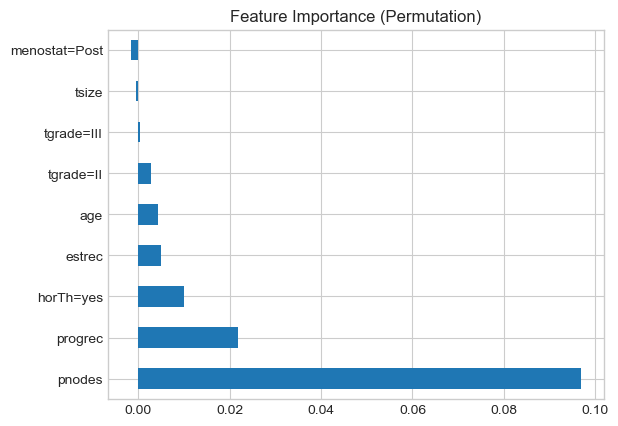

In [7]:
import pandas as pd

# Permutation importance is often better, but for speed we'll look at simple importances if available,
# or just skip to prediction. sksurv doesn't have a direct 'feature_importances_' attribute for RSF in older versions,
# but let's check permutation importance.
from sklearn.inspection import permutation_importance

result = permutation_importance(
    rsf, X_test, y_test, n_repeats=10, random_state=42
)

pd.Series(result.importances_mean, index=X.columns).sort_values(ascending=False).plot.barh()
plt.title("Feature Importance (Permutation)")
plt.show()

## 4. Predicting Survival Functions
Like Cox PH, RSF can predict the survival function for individual patients.

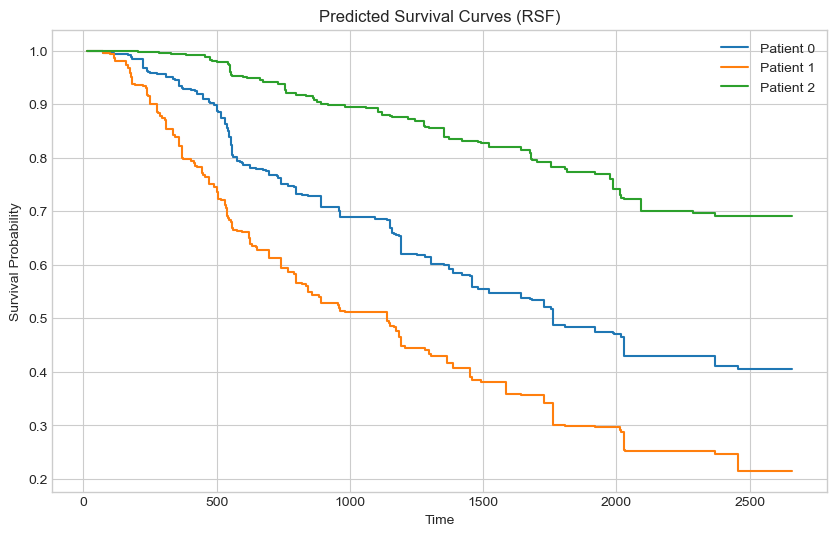

In [8]:
# Predict survival functions for the first 3 patients in test set
surv_funcs = rsf.predict_survival_function(X_test.iloc[:3])

plt.figure(figsize=(10, 6))
for i, fn in enumerate(surv_funcs):
    plt.step(fn.x, fn.y, where="post", label=f"Patient {i}")

plt.ylabel("Survival Probability")
plt.xlabel("Time")
plt.legend()
plt.title("Predicted Survival Curves (RSF)")
plt.show()

## 5. Gradient Boosting Survival Analysis
Gradient Boosting optimizes a loss function (like Cox Partial Likelihood) by iteratively adding weak learners.

In [9]:
from sksurv.ensemble import GradientBoostingSurvivalAnalysis

gbsa = GradientBoostingSurvivalAnalysis(n_estimators=100,
                                        learning_rate=0.1,
                                        max_depth=3,
                                        random_state=42)

gbsa.fit(X_train, y_train)

c_index_gbsa = gbsa.score(X_test, y_test)
print(f"Gradient Boosting C-index: {c_index_gbsa:.3f}")

Gradient Boosting C-index: 0.638


## Conclusion

| Model | C-index |
| --- | --- |
| Cox PH (Linear) | {c_index_cox:.3f} |
| Random Survival Forest | {c_index_rsf:.3f} |
| Gradient Boosting | {c_index_gbsa:.3f} |

Depending on the dataset, ML models often outperform linear models by capturing complex patterns. However, they can be harder to interpret.